 # Deduplicación de Clientes: Consolidación de Registros desde Múltiples Fuentes

  ## Objetivo

  Determinar la cantidad real de clientes únicos de la empresa, partiendo de tres fuentes de datos independientes que contienen registros duplicados tanto
  internamente como entre sí.

  ## Fuentes de Datos

  | Archivo | Descripción | Registros |
  |---|---|---|
  | `purchases.csv` | Transacciones de ventas. Contiene `customer_id` para clientes registrados y datos de invitados (`guest_first_name`, `guest_surname`,`guest_postcode`) para compras sin cuenta. | ~71500 |
  | `crm_export.csv` | Exportación del sistema CRM. Contiene nombre, apellido, edad y código postal de cada cliente. | ~7800 |
  | `customer_database.csv` | Base de datos de e-commerce. Misma estructura que el CRM, pero con una población de clientes considerablemente mayor. | ~23500 |

  ## Metodología

  El proceso de deduplicación se apoya en técnicas de **record linkage** implementadas con la librería `recordlinkage` de Python:

  1. **Codificación fonética (Soundex)** para normalizar variaciones ortográficas en nombres y apellidos.
  2. **Blocking por iniciales** para reducir el espacio de comparación, generando pares candidatos solo entre registros que comparten las mismas iniciales.
  3. **Métricas de similitud**: Jaro-Winkler para nombres y apellidos, Levenshtein para códigos postales, y comparación exacta para la edad.
  4. **Clasificación**: umbrales manuales para la deduplicación interna de cada dataset (donde se espera alta similitud entre duplicados), y
  **ECMClassifier** (Expectation-Maximization no supervisado) para el emparejamiento cruzado entre datasets, seguido de una validación exhaustiva par a par.

  ## Estructura del Notebook

  1. **Exploración de los datasets** — Carga, inspección de tipos, valores nulos y distribución inicial de clientes vs. invitados.
  2. **Preprocesamiento** — Limpieza de espacios, normalización de nombres (`title case`), codificación fonética y generación de iniciales.
  3. **Deduplicación interna del CRM** — `drop_duplicates()` para duplicados exactos, seguido de record linkage con umbrales manuales para duplicados
  difusos.
  4. **Deduplicación interna del e-commerce** — Mismo procedimiento aplicado al dataset de mayor volumen.
  5. **Emparejamiento cruzado (e-commerce vs. CRM)** — Indexación, comparación y clasificación con ECMClassifier, seguido de una revisión exhaustiva de cada
   combinación de atributos discrepantes para separar verdaderos positivos de falsos.
  6. **Resolución de emparejamientos "uno a muchos"** — Identificación y resolución de casos donde un registro se emparejó con múltiples registros del otro
  dataset.
  7. **Construcción de la tabla master** — Unificación de los registros deduplicados, incorporación de IDs provenientes de un sistema externo e integración
  de los invitados del dataset de ventas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import recordlinkage
from recordlinkage.preprocessing import phonetic
from helper_functions import preprocess_dataframe, show_pairs_dfs, show_dfs_lengths, get_boolean_masks

In [2]:
df_sales = pd.read_csv('data/purchases.csv')
df_crm = pd.read_csv('data/crm_export.csv')
df_ecommerce = pd.read_csv('data/customer_database.csv')

El resultado esperado debe ser un **único conjunto de datos** que represente tu modelo de datos de clientes.
Los datos procederán de las tres fuentes facilitadas, y deberás consolidarlos y eliminar los duplicados según corresponda.
Este modelo de datos debe estar estructurado de tal forma que toda la lógica para definir a los clientes ya esté implementada, y responder a la pregunta «¿Cuántos clientes tenemos?» debería ser tan sencillo como contar las filas.

## Explorando los datasets


In [3]:
print(f'Número de registros en  tabla de ventas: {df_sales.shape[0]}')
print(f'Número de registros en tabla crm: {df_crm.shape[0]}')
print(f'Número de registros en tabla ecommerce: {df_ecommerce.shape[0]}')

Número de registros en  tabla de ventas: 71519
Número de registros en tabla crm: 7825
Número de registros en tabla ecommerce: 23476


In [4]:
df_crm.sample(5)

,customer_id,first_name,surname,postcode,age
7703,17440,Max,Cooper,PO61NN,47
199,33051,Amelia,Cook,PO872DH,47
4311,15947,Bailey,Wright,PO200HH,20
5129,15310,Joshua,Holmes,NW908RR,49
7174,26823,Adan,Harrison,EX423JU,41


In [5]:
df_ecommerce.sample(5)

,customer_id,first_name,surname,postcode,age
10424,22266,Alexander,White,SO597LQ,44
10185,23987,Ross,King,SW293NE,62
15031,18872,Erin,Wilkinson,RG150RH,59
2240,28365,Kian,Cook,SW122AG,64
19575,1056,Bethany,Wilson,DE256NJ,21


In [6]:
df_sales.sample(5)

,event_time,product_id,category_id,category_code,brand,price,session_id,customer_id,guest_first_name,guest_surname,guest_postcode
47547,2022-10-21 04:10:20+00:00,10800004,2053013554994348409,NaN,maxwell,22.91,06826825-e6e4-44fa-b57d-053886e8132f,29520.0,NaN,NaN,NaN
1558,2022-10-01 16:56:08+00:00,5000741,2053013566100866035,appliances.sewing_machine,brother,160.88,cdd4b358-9b72-4b47-be3b-2b9023789dbd,21153.0,NaN,NaN,NaN
18904,2022-10-10 02:11:19+00:00,1004958,2053013555631882655,electronics.smartphone,xiaomi,342.09,1414e01a-abdc-4960-bc60-59c3d941ee34,21307.0,NaN,NaN,NaN
48713,2022-10-21 11:28:51+00:00,1307310,2053013558920217191,computers.notebook,acer,283.12,4d3bdec5-d012-4ff3-a2a6-d69b266f3d8f,2139.0,NaN,NaN,NaN
1141,2022-10-01 12:42:58+00:00,1004805,2053013555631882655,electronics.smartphone,xiaomi,138.46,7bab1ddf-f7af-419f-8262-1ff1111161ec,23929.0,NaN,NaN,NaN


In [7]:
df_crm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7825 entries, 0 to 7824
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  7825 non-null   int64 
 1   first_name   7825 non-null   object
 2   surname      7825 non-null   object
 3   postcode     7825 non-null   object
 4   age          7825 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 305.8+ KB


In [8]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23476 entries, 0 to 23475
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  23476 non-null  int64 
 1   first_name   23476 non-null  object
 2   surname      23476 non-null  object
 3   postcode     23476 non-null  object
 4   age          23476 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 917.2+ KB


In [9]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71519 entries, 0 to 71518
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_time        71519 non-null  object 
 1   product_id        71519 non-null  int64  
 2   category_id       71519 non-null  int64  
 3   category_code     54780 non-null  object 
 4   brand             65812 non-null  object 
 5   price             71519 non-null  float64
 6   session_id        71519 non-null  object 
 7   customer_id       53071 non-null  float64
 8   guest_first_name  18448 non-null  object 
 9   guest_surname     18448 non-null  object 
 10  guest_postcode    18448 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 6.0+ MB


In [10]:
df_sales

,event_time,product_id,category_id,category_code,brand,price,session_id,customer_id,guest_first_name,guest_surname,guest_postcode
0,2022-10-01 02:26:08+00:00,32701106,2055156924466332447,NaN,shimano,95.21,64c68405-7002-4ce0-9604-a4c2e1f7384b,NaN,MICHAEL,MASON,RG497ZQ
1,2022-10-01 02:28:32+00:00,9400066,2053013566067311601,NaN,jaguar,164.20,3b7d6741-3c82-4c75-8015-6f54b52612e0,7466.0,NaN,NaN,NaN
2,2022-10-01 02:31:01+00:00,1004238,2053013555631882655,electronics.smartphone,apple,1206.40,38c6d3f7-6c32-4fed-bca6-ef98e1746386,NaN,COLE,WILKINSON,SW75TQ
3,2022-10-01 02:33:31+00:00,11300059,2053013555531219353,electronics.telephone,texet,17.48,3398c966-7846-4186-89be-323daad735b9,NaN,MOHAMMED,RICHARDS,RG150RE
4,2022-10-01 02:40:18+00:00,17300751,2053013553853497655,NaN,versace,77.22,11e3a573-01b9-4794-b513-e7d8a4fcac83,31266.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
71514,2022-10-31 23:25:29+00:00,1004856,2053013555631882655,electronics.smartphone,samsung,128.42,2f794d64-796b-4a40-a778-5aa4682845a6,5750.0,NaN,NaN,NaN
71515,2022-10-31 23:25:29+00:00,1004856,2053013555631882655,electronics.smartphone,samsung,128.42,eeeb85a4-3809-4498-af79-ae91c6bfec8c,NaN,HARLEY,THOMAS,M625UB
71516,2022-10-31 23:44:56+00:00,1005074,2053013555631882655,electronics.smartphone,samsung,1142.62,ce520a95-f8eb-4c7a-9999-20eb12d26305,560068016.0,NaN,NaN,NaN
71517,2022-10-31 23:46:47+00:00,1480558,2053013561092866779,computers.desktop,netechnics,1055.34,80ba8f6f-6385-4ff3-b0c6-74ca812bcdcb,NaN,LEAH,BUTLER,LS433YR


In [11]:
guest_columns = ['guest_first_name', 'guest_surname', 'guest_postcode']
customer_ids_amount = len(df_sales['customer_id'].unique())
guests_amount = len(df_sales[guest_columns].drop_duplicates())
print(f'Número de ids únicos en tabla de ventas: {customer_ids_amount - 1}') # - 1 para remover el valor NaN que se cuenta
print(f'Número de guest tabla de ventas: {guests_amount}')

Número de ids únicos en tabla de ventas: 24961
Número de guest tabla de ventas: 8301


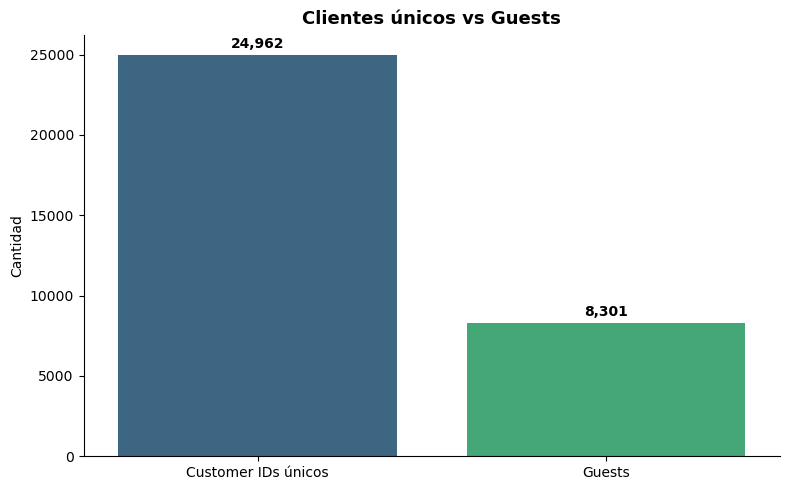

In [12]:
ejex = ['Customer IDs únicos', 'Guests']
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=ejex, y=[customer_ids_amount, guests_amount], hue= ejex, palette='viridis', ax=ax)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3, fontweight='bold')
ax.bar_label(ax.containers[1], fmt='{:,.0f}', padding=3, fontweight='bold')
ax.set_title('Clientes únicos vs Guests', fontweight='bold', fontsize=13, pad=8)
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
sns.despine()
plt.tight_layout()
plt.show()

Hay alrededor de 25 000 identificadores de cliente únicos, que representan a los clientes registrados, y otros 8 000 visitantes únicos estimados, por lo que, solo teniendo en cuenta las compras, se estima que el número máximo de clientes ronda los 33 000. Se debe tener en cuenta que es un estimado ya que más adelante se indagará si hay cuentas duplicadas, y esta cifra podría reducirse si encuentran duplicados.


In [13]:
print(f'Total de registros desde las 3 fuentes de datos: {(len(df_sales) + len(df_ecommerce) + len(df_crm)):,}')

Total de registros desde las 3 fuentes de datos: 102,820


Primero me enfocaréenr encontrar los pares duplicados que puedan existir en df_ecommerce y df_crm. Se utiliza la libreria recordlinkage para facilitar la busqueda de los posibles duplicados
## Preprocesamiento
- Standiranzado y limpiando las columnas que se utilizaran para realizar el matching


In [14]:
df_crm = preprocess_dataframe(df_crm, index_name='customer_id', dataset_name='df_crm')
df_crm.head(5)

df_crm: 7825 rows after preprocessing


,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT,H400,R262,HR
27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX,D540,O500,DO
7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA,E456,R240,ER
2569,Paige,Roberts,DE732EP,61,Paige,Roberts,DE732EP,P200,R163,PR
9195,Matilda,Young,LS670FU,78,Matilda,Young,LS670FU,M343,Y520,MY


In [15]:
df_ecommerce = preprocess_dataframe(df_ecommerce, index_name='customer_id', dataset_name='df_ecommerce')
df_ecommerce.head(5)

df_ecommerce: 23476 rows after preprocessing


,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY
14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU,N350,K520,NK
15306,Jack,Moore,NW908RR,26,Jack,Moore,NW908RR,J200,M600,JM
24971,Alexander,Roberts,SW500HW,85,Alexander,Roberts,SW500HW,A425,R163,AR


## Encontrando registros duplicados en **df_crm** dataset


In [16]:
df_crm.head(3)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT,H400,R262,HR
27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX,D540,O500,DO
7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA,E456,R240,ER


In [17]:
crm_records_before_cleaning = len(df_crm)
crm_records_duplicados = len(df_crm[df_crm.duplicated()])
print(f'Número de registros crm dataset: {crm_records_before_cleaning}')
print(f'Número de registros duplicados en crm dataset: {crm_records_duplicados}')
df_crm_no_duplicated = df_crm.drop_duplicates()
print(f'Número de registros en crm sin duplicados {len(df_crm_no_duplicated)}')


Número de registros crm dataset: 7825
Número de registros duplicados en crm dataset: 406
Número de registros en crm sin duplicados 7419


## Indexación/Blocking

In [18]:
indexer_crm = recordlinkage.Index()
indexer_crm.block(on='initials')
possible_pairs_crm = indexer_crm.index(df_crm_no_duplicated)
possible_pairs_crm

MultiIndex([(31071,  8442),
            (24442, 30015),
            (32838, 16482),
            ( 5182, 30344),
            ( 9402, 20371),
            ( 6387, 28385),
            ( 7880, 21401),
            ( 4059, 25715),
            ( 9438, 31388),
            (26363, 24184),
            ...
            (12684, 23232),
            (12684, 32840),
            (12684, 26946),
            (12684, 13829),
            (12684, 20964),
            (12684, 12803),
            (12684,  2313),
            (12684, 32288),
            (12684, 14870),
            (12684,  9446)],
           names=['customer_id_1', 'customer_id_2'], length=127177)

## Comparasion

In [19]:
#levenshtein para postcode
#jarowinkler para nombres y apellidos
crm_comp = recordlinkage.Compare()
crm_comp.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
crm_comp.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
crm_comp.exact('age', 'age', label='age')
crm_comp.string('postcode_cleaned', 'postcode_cleaned', method='levenshtein', label='postcode')
crm_comparison_output = crm_comp.compute(possible_pairs_crm, df_crm_no_duplicated)
crm_comparison_output

first_name   surname  age  postcode
customer_id_1 customer_id_2                                     
31071         8442             0.638889  1.000000    0  0.000000
24442         30015            0.611111  0.550000    0  0.000000
32838         16482            0.826667  0.527778    0  0.000000
5182          30344            1.000000  0.483333    0  0.142857
9402          20371            0.447619  0.550000    0  0.142857
...                                 ...       ...  ...       ...
12684         12803            0.540741  0.458333    0  0.000000
              2313             0.904762  0.472222    0  0.142857
              32288            1.000000  0.611111    0  0.142857
              14870            0.588624  0.500000    0  0.000000
              9446             1.000000  0.611111    0  0.142857

[127177 rows x 4 columns]

## Clasificación
- Dado que estoy buscando posibles duplicados en el mismo conjunto de datos, optaré por una clasificación 'manual', ya que por 'integridad' de los datos registrados en la misma base, las comparaciones entre columnas del mismo conjunto de datos deberían reflejar un alto grado de similitud entre los posibles registros duplicados.

In [20]:
filter_manual_approach_crm =  (
    crm_comparison_output[(crm_comparison_output['first_name'] > 0.85)
                          & (crm_comparison_output['surname'] > 0.85) 
                          & (crm_comparison_output['age'] == 1 ) 
                          & (crm_comparison_output['postcode'] > 0.85)])
filter_manual_approach_crm

,,first_name,surname,age,postcode
customer_id_1,customer_id_2,,,,
27355,24068,1.000000,0.883333,1,1.0
3942,29729,0.914286,1.000000,1,1.0
6443,28152,0.920000,0.950000,1,1.0
11474,30459,0.922222,1.000000,1,1.0
23589,30756,0.911111,1.000000,1,1.0
...,...,...,...,...,...
12564,29182,1.000000,0.866667,1,1.0
31193,24631,1.000000,0.893333,1,1.0
28284,24002,1.000000,0.933333,1,1.0


In [21]:
show_pairs_dfs(df_crm, df_crm, filter_manual_approach_crm.index, random_samples=True, number_of_samples=5)

first_name             Benjamin
surname                  Gibson
postcode                SO147PE
age                           1
first_name_cleaned     Benjamin
surname_cleaned          Gibson
postcode_cleaned        SO147PE
phonetic_first_name        B525
phonetic_surname           G125
initials                     BG
Name: 21077, dtype: object
first_name             Benjahin
surname                  Gibson
postcode                SO147PE
age                           1
first_name_cleaned     Benjahin
surname_cleaned          Gibson
postcode_cleaned        SO147PE
phonetic_first_name        B525
phonetic_surname           G125
initials                     BG
Name: 27463, dtype: object
------------------------
first_name             George
surname                 Evans
postcode               M560SZ
age                        39
first_name_cleaned     George
surname_cleaned         Evans
postcode_cleaned       M560SZ
phonetic_first_name      G620
phonetic_surname         E152
initials   

### Aunque los emparejamientos parecen bastantes precisos voy a chequear por posibles falsos emparejamientos


In [22]:
left_pairs_index_crm = filter_manual_approach_crm.index.get_level_values(0)
right_pairs_index_crm = filter_manual_approach_crm.index.get_level_values(1)

In [23]:
columns_to_check = ['first_name_cleaned', 'surname_cleaned', 'age', 'postcode_cleaned']
suffix = '_cleaned'
diff_crm = {} # dictionatio que almacena para cada columna boolean masks
for column in columns_to_check:
    key = 'diff_' + column.removesuffix(suffix) + '_crm_pairs'
    diff_crm[key] = filter_manual_approach_crm[~(df_crm_no_duplicated.loc[left_pairs_index_crm, column].values == df_crm_no_duplicated.loc[right_pairs_index_crm, column].values)]

In [24]:
show_dfs_lengths(diff_crm)

Número de emparejamientos diff_first_name_crm_pairs: 40
Número de emparejamientos diff_surname_crm_pairs: 36
Número de emparejamientos diff_age_crm_pairs: 0
Número de emparejamientos diff_postcode_crm_pairs: 0


In [25]:
mulindex_crm_pairs_name_and_surname_diff = (diff_crm['diff_first_name_crm_pairs'].index
                                            .intersection(diff_crm['diff_surname_crm_pairs'].index))

print(f"Existen {len(mulindex_crm_pairs_name_and_surname_diff)} emparejamientos donde name y surname son diferentes")

Existen 12 emparejamientos donde name y surname son diferentes


In [26]:
mulindex_crm_pairs_just_name_diff = (diff_crm['diff_first_name_crm_pairs'].index
                                     .difference(mulindex_crm_pairs_name_and_surname_diff))

print(f"Existen {len(mulindex_crm_pairs_just_name_diff)} emparejamientos donde name es diferente")

Existen 28 emparejamientos donde name es diferente


In [27]:
mulindex_crm_pairs_just_surname_diff = (diff_crm['diff_surname_crm_pairs'].index
                                        .difference(mulindex_crm_pairs_name_and_surname_diff))

print(f"Existen {len(mulindex_crm_pairs_just_surname_diff)} emparejamientos donde surname es diferente")

Existen 24 emparejamientos donde surname es diferente


In [28]:
total_of_wrong_emparejamientos_crm = (
    (mulindex_crm_pairs_just_name_diff)
    .union(mulindex_crm_pairs_just_surname_diff)
    .union(mulindex_crm_pairs_name_and_surname_diff))

print(f'De los emparejamientos en crm existen {len(total_of_wrong_emparejamientos_crm)} posibles falsos duplicados.')

De los emparejamientos en crm existen 64 posibles falsos duplicados.


In [29]:
show_pairs_dfs(df_crm_no_duplicated, df_crm, total_of_wrong_emparejamientos_crm, False)

first_name              Jayden
surname                   Webb
postcode               DE237GG
age                          5
first_name_cleaned      Jayden
surname_cleaned           Webb
postcode_cleaned       DE237GG
phonetic_first_name       J350
phonetic_surname          W100
initials                    JW
Name: 741, dtype: object
first_name              Jaydem
surname                   Webb
postcode               DE237GG
age                          5
first_name_cleaned      Jaydem
surname_cleaned           Webb
postcode_cleaned       DE237GG
phonetic_first_name       J350
phonetic_surname          W100
initials                    JW
Name: 29911, dtype: object
------------------------
first_name              Brandon
surname                Robinson
postcode                DE250HA
age                          21
first_name_cleaned      Brandon
surname_cleaned        Robinson
postcode_cleaned        DE250HA
phonetic_first_name        B653
phonetic_surname           R152
initials       

- Revisé manualmente los 64 pares, todos ellos coincidentes con errores de introducción de datos. No hay diferencias entre edades o códigos postales, solo errores ortográficos entre el nombre y los apellidos, por lo que he decidido considerar estas coincidencias "erróneas" como correctas.
Ahora vamos a mantener las coincidencias del nivel 0 del filtro MultiIndex filter_manual_approach_crm y eliminar del df_crm los duplicados que pertenecen al nivel 1 del filtro MultiIndex filter_manual_approach_crm.

In [30]:
df_crm_deduped = df_crm_no_duplicated.drop(filter_manual_approach_crm.index.get_level_values(1))
print(f'Número de registros en crm luego de eliminar duplicados: {df_crm_deduped.shape[0]}')

Número de registros en crm luego de eliminar duplicados: 7355


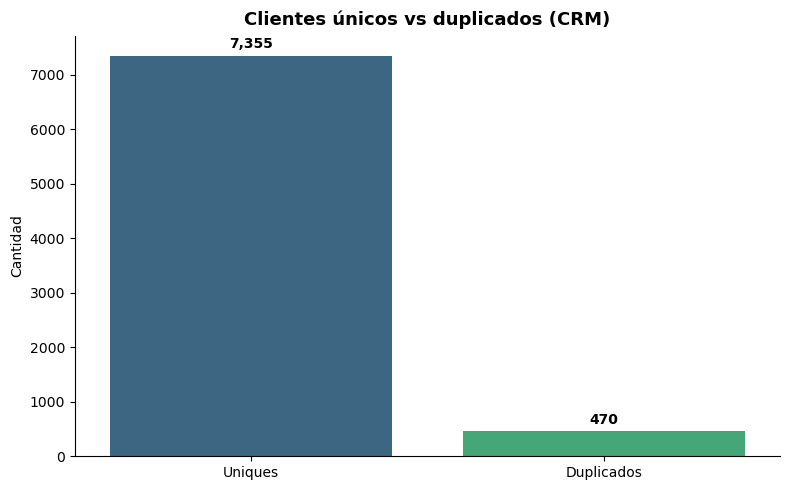

In [31]:
ejex = ['Uniques', 'Duplicados']
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=ejex, y=[len(df_crm_deduped), crm_records_duplicados + len(filter_manual_approach_crm)], hue= ejex, palette='viridis', ax=ax)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3, fontweight='bold')
ax.bar_label(ax.containers[1], fmt='{:,.0f}', padding=3, fontweight='bold')
ax.set_title('Clientes únicos vs duplicados (CRM)', fontweight='bold', fontsize=13, pad=8)
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
sns.despine()
plt.tight_layout()
plt.show()


## Encontrando duplicados en df_ecommerce dataset


In [32]:
ecom_records_before_cleaning = len(df_ecommerce)
ecom_records_duplicados = len(df_ecommerce[df_ecommerce.duplicated()])
print(f'Número de registros en ecommerce dataset: {ecom_records_before_cleaning}')
print(f'Número de registros duplicados: {ecom_records_duplicados}')
df_ecommerce_no_duplicated = df_ecommerce.drop_duplicates()
print(f'Número de registros luego de eliminar duplicados {len(df_ecommerce_no_duplicated)}')

Número de registros en ecommerce dataset: 23476
Número de registros duplicados: 3587
Número de registros luego de eliminar duplicados 19889


In [33]:
indexer_ecommerce_db = recordlinkage.Index()
indexer_ecommerce_db.block('initials')
possible_pairs_customer_db = indexer_ecommerce_db.index(df_ecommerce_no_duplicated)
possible_pairs_customer_db

MultiIndex([(21784, 24971),
            (25094, 30178),
            ( 4361,   509),
            ( 5887,  7404),
            (   93, 18792),
            ( 6781,  7276),
            (13668, 22755),
            (32122, 24971),
            (32122, 21784),
            (29571, 22755),
            ...
            (29494, 31084),
            (29494, 23825),
            (29494, 24242),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918),
            (29494, 17508),
            (29494,  3695),
            (29494, 14995)],
           names=['customer_id_1', 'customer_id_2'], length=932403)

In [34]:
#levenshtein para postcode
#jarowinkler para nombres y apellidos
ecommerce_db_comp = recordlinkage.Compare()
ecommerce_db_comp.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
ecommerce_db_comp.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
ecommerce_db_comp.exact('age', 'age', label='age' )
ecommerce_db_comp.string('postcode_cleaned', 'postcode_cleaned', method='levenshtein', label='postcode')
ecommercedb_comparison_output = ecommerce_db_comp.compute(possible_pairs_customer_db, df_ecommerce_no_duplicated)
ecommercedb_comparison_output

first_name   surname  age  postcode
customer_id_1 customer_id_2                                     
21784         24971            0.518519  0.955556    0  0.142857
25094         30178            1.000000  1.000000    0  0.142857
4361          509              0.633333  0.527778    0  0.000000
5887          7404             0.800000  0.666667    0  0.285714
93            18792            1.000000  0.555556    0  0.000000
...                                 ...       ...  ...       ...
29494         6418             0.760000  0.511905    0  0.000000
              10918            0.483333  0.464286    0  0.285714
              17508            0.483333  0.492063    0  0.142857
              3695             0.483333  0.866667    0  0.285714
              14995            0.600000  0.539683    0  0.000000

[932403 rows x 4 columns]

In [35]:
filter_manual_approach_ecommercedb = (
    ecommercedb_comparison_output[(ecommercedb_comparison_output['first_name'] > 0.85) 
                                 & (ecommercedb_comparison_output['surname'] > 0.85) 
                                 & (ecommercedb_comparison_output['age'] == 1) 
                                 & (ecommercedb_comparison_output['postcode'] > 0.85)])
filter_manual_approach_ecommercedb

,,first_name,surname,age,postcode
customer_id_1,customer_id_2,,,,
29567,3415,1.000000,0.955556,1,1.000000
31474,1492,0.933333,0.922222,1,1.000000
9632,31018,1.000000,0.933333,1,1.000000
20608,28770,1.000000,0.977778,1,1.000000
18439,32122,0.850000,1.000000,1,1.000000
...,...,...,...,...,...
28557,15329,0.922222,0.900000,1,1.000000
30392,23116,1.000000,0.922222,1,1.000000
4220,30722,1.000000,0.925000,1,1.000000


In [36]:
left_pairs_index_customer_db = filter_manual_approach_ecommercedb.index.get_level_values(0)
right_pairs_index_ecommerce_db = filter_manual_approach_ecommercedb.index.get_level_values(1)

## Buscando diferencias entre nombre, apellido, edad and código postal

In [37]:
diff_ecommerce_db = {} # dictionario que almacena para cada columna boolean masks
for column in columns_to_check:
    key = column.removesuffix(suffix) + '_diff'
    diff_ecommerce_db[key] = filter_manual_approach_ecommercedb[~((df_ecommerce_no_duplicated.loc[left_pairs_index_customer_db, column].values) == (df_ecommerce_no_duplicated.loc[right_pairs_index_ecommerce_db, column].values))]

In [38]:
show_dfs_lengths(diff_ecommerce_db)

Número de emparejamientos first_name_diff: 309
Número de emparejamientos surname_diff: 321
Número de emparejamientos age_diff: 0
Número de emparejamientos postcode_diff: 3


In [39]:
mulindex_custdb_pairs_surname_name_diff = diff_ecommerce_db['first_name_diff'].index.intersection(diff_ecommerce_db['surname_diff'].index)
print(f"Existen {len(mulindex_custdb_pairs_surname_name_diff)} emparejamientos donde surname and name son diferentes")

Existen 80 emparejamientos donde surname and name son diferentes


In [40]:
mulindex_custdb_pairs_just_surname_diff = diff_ecommerce_db['surname_diff'].index.difference(diff_ecommerce_db['first_name_diff'].index)
print(f"Existen {len(mulindex_custdb_pairs_just_surname_diff)} emparejamientos donde solo surname es diferente")

Existen 241 emparejamientos donde solo surname es diferente


In [41]:
mulindex_custdb_pairs_just_name_diff = diff_ecommerce_db['first_name_diff'].index.difference(diff_ecommerce_db['surname_diff'].index)
print(f"Existen {len(mulindex_custdb_pairs_just_name_diff)} emparejamientos donde solo name es diferente")

Existen 229 emparejamientos donde solo name es diferente


In [42]:
show_pairs_dfs(df_ecommerce_no_duplicated, df_ecommerce_no_duplicated, mulindex_custdb_pairs_surname_name_diff, random_samples=True, number_of_samples=10)

first_name              Hrrvey
surname                 Hrrvey
postcode               SO527SQ
age                         51
first_name_cleaned      Hrrvey
surname_cleaned         Hrrvey
postcode_cleaned       SO527SQ
phonetic_first_name       H610
phonetic_surname          H610
initials                    HH
Name: 29429, dtype: object
first_name              Harvey
surname                 Harvey
postcode               SO527SQ
age                         51
first_name_cleaned      Harvey
surname_cleaned         Harvey
postcode_cleaned       SO527SQ
phonetic_first_name       H610
phonetic_surname          H610
initials                    HH
Name: 21892, dtype: object
------------------------
first_name              Brooxe
surname                  Baxer
postcode               SW937XP
age                         48
first_name_cleaned      Brooxe
surname_cleaned          Baxer
postcode_cleaned       SW937XP
phonetic_first_name       B620
phonetic_surname          B260
initials              

- Tras comprobar algunas de las coincidencias que contienen errores en el apellido y el nombre, se observa que se trata de errores ortográficos menores. Por lo tanto, estas coincidencias 'erróneas' se considerarán verdaderos duplicados.

In [43]:
df_ecommerce_deduped =  df_ecommerce_no_duplicated.drop(filter_manual_approach_ecommercedb.index.get_level_values(1))
df_ecommerce_deduped.shape[0]

19337

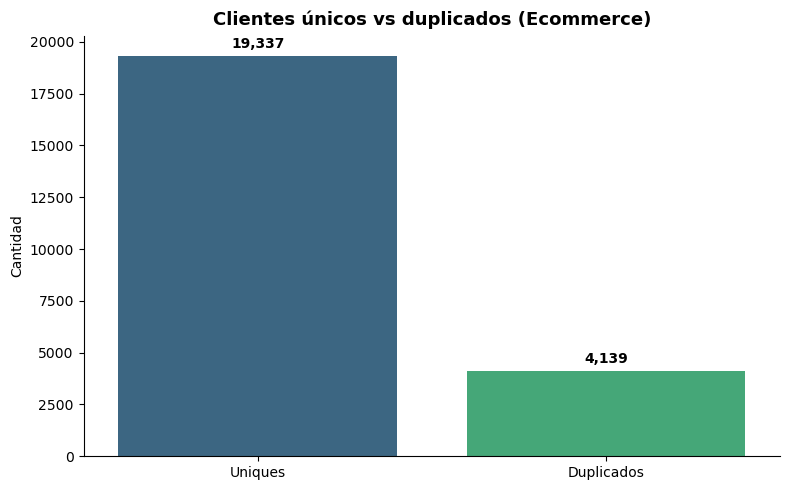

In [44]:
ejex = ['Uniques', 'Duplicados']
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=ejex, y=[len(df_ecommerce_deduped), ecom_records_duplicados + len(filter_manual_approach_ecommercedb)], hue= ejex, palette='viridis', ax=ax)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3, fontweight='bold')
ax.bar_label(ax.containers[1], fmt='{:,.0f}', padding=3, fontweight='bold')
ax.set_title('Clientes únicos vs duplicados (Ecommerce)', fontweight='bold', fontsize=13, pad=8)
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
sns.despine()
plt.tight_layout()
plt.show()

## Encontrar posibles duplicados entre ecommerce y crm datasets

## Indexación

In [45]:
indixes = recordlinkage.Index()
indixes.block('initials')
indx_emparejamientos = indixes.index(df_ecommerce_deduped, df_crm_deduped)
indx_emparejamientos

MultiIndex([( 1641, 21710),
            ( 1641, 27643),
            ( 1641,  8174),
            ( 1641,  1641),
            ( 1641, 32623),
            ( 1641, 23330),
            ( 1641, 27768),
            ( 1641, 29180),
            ( 1641, 21330),
            ( 1641,  6002),
            ...
            (29494, 15904),
            (29494, 18273),
            (29494, 21772),
            (29494,  1886),
            (29494,  4201),
            (29494,  8108),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918)],
           names=['customer_id_1', 'customer_id_2'], length=669701)

In [46]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, indx_emparejamientos, True, 3)

first_name               Jamie
surname                   Ward
postcode               DE500JF
age                         54
first_name_cleaned       Jamie
surname_cleaned           Ward
postcode_cleaned       DE500JF
phonetic_first_name       J500
phonetic_surname          W630
initials                    JW
Name: 1708, dtype: object
first_name                James
surname                Williams
postcode                DE352AN
age                          51
first_name_cleaned        James
surname_cleaned        Williams
postcode_cleaned        DE352AN
phonetic_first_name        J520
phonetic_surname           W452
initials                     JW
Name: 1208, dtype: object
------------------------
first_name               Ethan
surname                Johnson
postcode               SO976NU
age                         44
first_name_cleaned       Ethan
surname_cleaned        Johnson
postcode_cleaned       SO976NU
phonetic_first_name       E350
phonetic_surname          J525
initials      

## Comparación

In [47]:
#levenshtein para postcode
#jarowinkler para nombres y apellidos

comparisons = recordlinkage.Compare()
comparisons.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
comparisons.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
comparisons.exact('age', 'age', label='age')
comparisons.string('postcode_cleaned', 'postcode_cleaned', method='levenshtein', label='postcode')
comparisons.exact('phonetic_first_name', 'phonetic_first_name', label='phonetic_first_name')
comparisons.exact('phonetic_surname', 'phonetic_surname', label='phonetic_surname')
comparisons_output = comparisons.compute(indx_emparejamientos, df_ecommerce_deduped, df_crm_deduped)
comparisons_output

first_name   surname  age  postcode  \
customer_id_1 customer_id_2                                        
1641          21710            0.666667  0.737500    0  0.142857   
              27643            0.472222  0.950000    0  0.285714   
              8174             0.472222  0.625000    0  0.000000   
              1641             1.000000  1.000000    1  1.000000   
              32623            0.633333  0.569444    0  0.142857   
...                                 ...       ...  ...       ...   
29494         8108             0.600000  0.523810    0  0.000000   
              2651             0.483333  0.511905    0  0.142857   
              7086             0.483333  0.436508    0  0.000000   
              6418             0.760000  0.511905    0  0.000000   
              10918            0.483333  0.464286    0  0.285714   

                             phonetic_first_name  phonetic_surname  
customer_id_1 customer_id_2                                         
1641          21710                            0                 0  
              27643                            0                 1  
              8174                             0                 0  
              1641                             1                 1  
              32623                            1                 0  
...                                          ...               ...  
29494         8108                             0                 0  
              2651                             0                 0  
              7086                             0                 0  
              6418                             0                 0  
              10918                            0                 0  

[669701 rows x 6 columns]

## Clasificación

In [48]:
# Unsupervised
# ECMClassifier

ecmc = recordlinkage.ECMClassifier(init='jaro', binarize=0.5, max_iter=100)
ecmc.fit(comparisons_output)
emparejamientos_unsupervised_result = ecmc.predict(comparisons_output)
emparejamientos_unsupervised_result

MultiIndex([( 1641,  1641),
            (24796, 26110),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 30781),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (24266, 24266),
            ...
            (30532, 26494),
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (22059, 28201),
            (22009, 22010),
            ( 5982,  6496),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=6286)

In [49]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, emparejamientos_unsupervised_result, True)

first_name               Holly
surname                 Harris
postcode               LS220HX
age                         31
first_name_cleaned       Holly
surname_cleaned         Harris
postcode_cleaned       LS220HX
phonetic_first_name       H400
phonetic_surname          H620
initials                    HH
Name: 28928, dtype: object
first_name                Holly
surname                Harrison
postcode                LS220HX
age                          31
first_name_cleaned        Holly
surname_cleaned        Harrison
postcode_cleaned        LS220HX
phonetic_first_name        H400
phonetic_surname           H625
initials                     HH
Name: 7796, dtype: object
------------------------
first_name               Oscar
surname                 Palmer
postcode               SO433HB
age                          0
first_name_cleaned       Oscar
surname_cleaned         Palmer
postcode_cleaned       SO433HB
phonetic_first_name       O260
phonetic_surname          P456
initials     

In [50]:
pd.Series(emparejamientos_unsupervised_result.get_level_values(0)).value_counts()

customer_id_1
25622    3
7934     2
21756    2
26053    2
16812    2
        ..
14993    1
12608    1
27725    1
19833    1
5679     1
Name: count, Length: 6174, dtype: int64

In [51]:
pd.Series(emparejamientos_unsupervised_result.get_level_values(1)).value_counts().head(5)

customer_id_2
24689    5
24719    5
7935     3
14803    3
30193    3
Name: count, dtype: int64

In [52]:
emparejamientos_unsupervised_result[emparejamientos_unsupervised_result.get_level_values(1) == 24719 ]

MultiIndex([(24689, 24719),
            (24719, 24719),
            (24718, 24719),
            (21554, 24719),
            (21756, 24719)],
           names=['customer_id_1', 'customer_id_2'])

In [53]:
show_pairs_dfs(df_ecommerce_deduped, 
               df_crm_deduped, 
               emparejamientos_unsupervised_result[emparejamientos_unsupervised_result.get_level_values(1) == 24719 ],
               False)

first_name              Isabella
surname                Robertson
postcode                 SW433XU
age                           22
first_name_cleaned      Isabella
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I214
phonetic_surname            R163
initials                      IR
Name: 24689, dtype: object
first_name              Isabelle
surname                Robertson
postcode                 SW433XU
age                           10
first_name_cleaned      Isabelle
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I214
phonetic_surname            R163
initials                      IR
Name: 24719, dtype: object
------------------------
first_name              Isabelle
surname                Robertson
postcode                 SW433XU
age                           10
first_name_cleaned      Isabelle
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I2

- Chequeamos manualmente los emparejamientos relizados en el id **24719** que proviene del crm dataset, podemos ver que dicho id solo es emparejado correctamente con el id **24719** del db_customer dataset (ecommerce), los otros emparejamientos tienen diferencias notables en edad, ciertos errores en los nombres o apellido y codigo postal, por lo tanto manualmente voy a buscar y descartar estos falsos positivos emparejamientos. 


In [54]:
left_pairs_index_emparejamientos = emparejamientos_unsupervised_result.get_level_values(0)
right_pairs_index_emparejamientos = emparejamientos_unsupervised_result.get_level_values(1)


## Buscando errores de emparejamiento entre los distintos atributos 

In [55]:
diff_between_dataset_pairs = {}
for column in columns_to_check:
    key = column.removesuffix(suffix) + '_diff'
    diff_between_dataset_pairs[key] = (
        emparejamientos_unsupervised_result[~(df_ecommerce_deduped.loc[left_pairs_index_emparejamientos, column].values 
                                      == df_crm_deduped.loc[right_pairs_index_emparejamientos, column].values)]) 

In [56]:
show_dfs_lengths(diff_between_dataset_pairs)

Número de emparejamientos first_name_diff: 285
Número de emparejamientos surname_diff: 207
Número de emparejamientos age_diff: 299
Número de emparejamientos postcode_diff: 133


## Buscando errores de emparejamiento entre edad, nombre, apellido y codigo-postal


In [57]:
wrong_surname_name_age_postcode = (diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection(diff_between_dataset_pairs['postcode_diff']))
len(wrong_surname_name_age_postcode)

14

In [58]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, wrong_surname_name_age_postcode)

first_name               Jacob
surname                    Cox
postcode               SW937XN
age                         22
first_name_cleaned       Jacob
surname_cleaned            Cox
postcode_cleaned       SW937XN
phonetic_first_name       J210
phonetic_surname          C200
initials                    JC
Name: 31892, dtype: object
first_name              Joseph
surname                   Cook
postcode               SW433XX
age                         57
first_name_cleaned      Joseph
surname_cleaned           Cook
postcode_cleaned       SW433XX
phonetic_first_name       J210
phonetic_surname          C200
initials                    JC
Name: 24778, dtype: object
------------------------
first_name              Sophia
surname                  Jones
postcode               SO433HD
age                         40
first_name_cleaned      Sophia
surname_cleaned          Jones
postcode_cleaned       SO433HD
phonetic_first_name       S100
phonetic_surname          J520
initials              

- Se chequeo manualmente los emparejamientos de wrong_surname_name_age_postcode MultiIndex y efectivamente son falsos positivos y no se tratan de la misma persona

## Buscando errores de emparejamiento entre `nombres` y  solo `nombres`


In [59]:
columns = ['surname_cleaned', 'age', 'postcode_cleaned']
names_boolean_mask = get_boolean_masks(df_ecommerce_deduped, df_crm_deduped, diff_between_dataset_pairs['first_name_diff'], columns)
mulIndex_pairs_name_diff = (
    diff_between_dataset_pairs['first_name_diff']
    [names_boolean_mask['surname_cleaned'] & names_boolean_mask['age'] & names_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_name_diff)

134

In [60]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, mulIndex_pairs_name_diff, random_samples=True, number_of_samples=30)

first_name               Faith
surname                 Carter
postcode               LS806XB
age                          4
first_name_cleaned       Faith
surname_cleaned         Carter
postcode_cleaned       LS806XB
phonetic_first_name       F300
phonetic_surname          C636
initials                    FC
Name: 9314, dtype: object
first_name               Faitk
surname                 Carter
postcode               LS806XB
age                          4
first_name_cleaned       Faitk
surname_cleaned         Carter
postcode_cleaned       LS806XB
phonetic_first_name       F320
phonetic_surname          C636
initials                    FC
Name: 32233, dtype: object
------------------------
first_name             Elizabeth
surname                  Stevens
postcode                 SW744QX
age                            9
first_name_cleaned     Elizabeth
surname_cleaned          Stevens
postcode_cleaned         SW744QX
phonetic_first_name         E421
phonetic_surname            S315
initi

- Las coincidencias de mulIndex_pairs_name_diff MultiIndex se comprueban aleatoriamente de forma manual y se observan diferencias sutiles entre los nombres; por lo tanto, estas coincidencias se considerarán correctas.

## Buscando errores de emparejamiento entre `apellidos` y solo `apellidos`


In [61]:
columns = ['first_name_cleaned', 'age', 'postcode_cleaned']
surnnames_boolean_mask = get_boolean_masks(df_ecommerce_deduped, df_crm_deduped, diff_between_dataset_pairs['surname_diff'], columns)
mulIndex_pairs_surname_diff = (
    diff_between_dataset_pairs['surname_diff']
    [surnnames_boolean_mask['first_name_cleaned'] & surnnames_boolean_mask['age'] & surnnames_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_surname_diff)

128

In [62]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, mulIndex_pairs_surname_diff, random_samples=True, number_of_samples=30)

first_name                Jacob
surname                Phiiiips
postcode                SW988AF
age                           6
first_name_cleaned        Jacob
surname_cleaned        Phiiiips
postcode_cleaned        SW988AF
phonetic_first_name        J210
phonetic_surname           P120
initials                     JP
Name: 29844, dtype: object
first_name                Jacob
surname                Phillips
postcode                SW988AF
age                           6
first_name_cleaned        Jacob
surname_cleaned        Phillips
postcode_cleaned        SW988AF
phonetic_first_name        J210
phonetic_surname           P412
initials                     JP
Name: 26447, dtype: object
------------------------
first_name                Emma
surname                  Moore
postcode               PO200HJ
age                         13
first_name_cleaned        Emma
surname_cleaned          Moore
postcode_cleaned       PO200HJ
phonetic_first_name       E500
phonetic_surname          M600
in

- Las coincidencias de mulIndex_pairs_surname_diff MultiIndex se comprueban aleatoriamente de forma manual y se observan diferencias sutiles entre los apellidos; por lo tanto, estas coincidencias se considerarán correctas.


## Buscando errores de emparejamiento entre `edades` y solo `edades`

In [63]:
columns = ['first_name_cleaned', 'surname_cleaned', 'postcode_cleaned']
age_boolean_mask = get_boolean_masks(df_ecommerce_deduped, df_crm_deduped, diff_between_dataset_pairs['age_diff'], columns)
mulIndex_pairs_age_diff = (
    diff_between_dataset_pairs['age_diff']
    [age_boolean_mask['first_name_cleaned'] & age_boolean_mask['surname_cleaned'] & age_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_age_diff)

107

In [64]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, mulIndex_pairs_age_diff, random_samples=True, number_of_samples=30)

first_name              Oliver
surname                   Gray
postcode               PO466DU
age                          5
first_name_cleaned      Oliver
surname_cleaned           Gray
postcode_cleaned       PO466DU
phonetic_first_name       O416
phonetic_surname          G600
initials                    OG
Name: 16786, dtype: object
first_name              Oliver
surname                   Gray
postcode               PO466DU
age                          4
first_name_cleaned      Oliver
surname_cleaned           Gray
postcode_cleaned       PO466DU
phonetic_first_name       O416
phonetic_surname          G600
initials                    OG
Name: 29880, dtype: object
------------------------
first_name             Charlotte
surname                    Scott
postcode                 SW433XW
age                           21
first_name_cleaned     Charlotte
surname_cleaned            Scott
postcode_cleaned         SW433XW
phonetic_first_name         C643
phonetic_surname            S300
init

- De forma aleatoria se chequeo manualmente los emparejamientos de mulIndex_pairs_age_diffMultiIndex y se observa que si existen grandes difrencias entre las edades de muchos emparejamientos.

In [65]:
abs_age_difference = abs(
    df_ecommerce_deduped.loc[mulIndex_pairs_age_diff.get_level_values(0), 'age'].values 
    - df_crm_deduped.loc[mulIndex_pairs_age_diff.get_level_values(1), 'age'].values)
abs_age_difference

array([ 2,  2,  1, 23, 23, 21,  1, 37, 27, 28, 21, 32,  2,  1,  1,  2, 29,
       33,  1,  1,  1, 23, 37,  1,  1, 40,  1, 16,  7, 23, 40,  1,  5,  1,
       23, 33,  1,  9, 31, 18, 12,  1,  1, 46,  1,  2, 29,  4,  1,  1,  1,
        1,  1,  1, 23,  7, 28, 26, 37,  1, 35, 20,  1, 29, 30,  1,  1, 11,
        1, 11, 18,  1,  1, 15,  1,  2, 15,  1,  1, 36,  1,  1, 38, 30,  6,
        1,  7, 23,  9, 26,  1,  1, 20,  2, 22, 34, 25,  1,  1, 25,  1,  1,
        4, 54, 28,  5, 15])

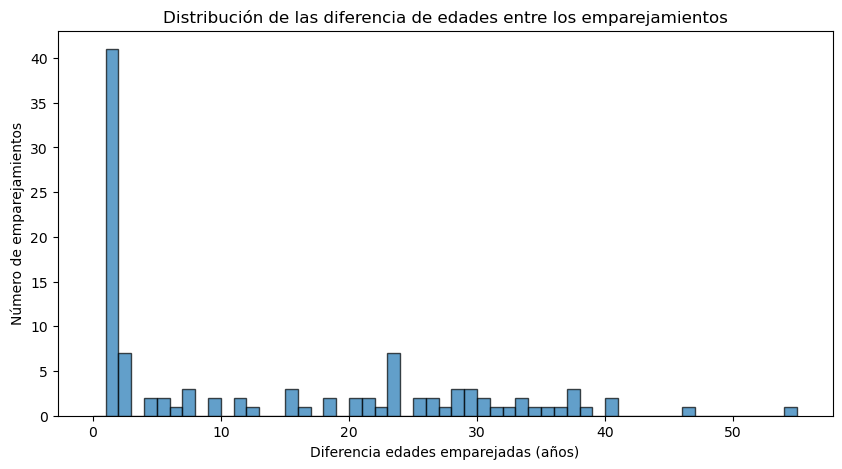

In [66]:
plt.figure(figsize=(10,5))
plt.hist(abs_age_difference, bins=range(0, max(abs_age_difference) + 2), edgecolor='black', alpha=0.7)
plt.xlabel('Diferencia edades emparejadas (años)')
plt.ylabel('Número de emparejamientos')
plt.title('Distribución de las diferencia de edades entre los emparejamientos')
plt.show()

In [67]:
print(f'Median: {np.median(abs_age_difference):.2f}')
print(f'90th percentile {np.percentile(abs_age_difference, 90):.2f}')
print(f'50th percentile {np.percentile(abs_age_difference, 50):.2f}')
print(f'40th percentile {np.percentile(abs_age_difference, 40):.2f}')
print(f'30th percentile {np.percentile(abs_age_difference, 30):.2f}')
print(f'25th percentile {np.percentile(abs_age_difference, 25):.2f}')


Median: 7.00
90th percentile 33.40
50th percentile 7.00
40th percentile 2.00
30th percentile 1.00
25th percentile 1.00


- Al observar la distribución de la diferencia de edad, se aplicará un límite de un año, lo que significa que las coincidencias en las que haya una diferencia superior a dos años se considerarán falsos positivos y, por lo tanto, personas diferentes.

In [68]:
positive_matches_age = mulIndex_pairs_age_diff[abs_age_difference <= 1]
len(positive_matches_age)

41

In [69]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, positive_matches_age)

first_name                Emma
surname                   King
postcode               EX121UA
age                         57
first_name_cleaned        Emma
surname_cleaned           King
postcode_cleaned       EX121UA
phonetic_first_name       E500
phonetic_surname          K520
initials                    EK
Name: 2904, dtype: object
first_name                Emma
surname                   King
postcode               EX121UA
age                         56
first_name_cleaned        Emma
surname_cleaned           King
postcode_cleaned       EX121UA
phonetic_first_name       E500
phonetic_surname          K520
initials                    EK
Name: 30622, dtype: object
------------------------
first_name               Alice
surname                 Walker
postcode               NW500AU
age                         51
first_name_cleaned       Alice
surname_cleaned         Walker
postcode_cleaned       NW500AU
phonetic_first_name       A420
phonetic_surname          W426
initials               

## Buscando errores de emparejamiento entre `código-postal` y solo `código-postal`



In [70]:
columns = ['first_name_cleaned', 'surname_cleaned', 'age']
postal_code_boolean_mask = get_boolean_masks(df_ecommerce_deduped, df_crm_deduped, diff_between_dataset_pairs['postcode_diff'], columns)
mulIndex_pairs_postcode_diff = (
    diff_between_dataset_pairs['postcode_diff']
    [postal_code_boolean_mask['first_name_cleaned'] & postal_code_boolean_mask['surname_cleaned'] & postal_code_boolean_mask['age']])
len(mulIndex_pairs_postcode_diff)

2

In [71]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, mulIndex_pairs_postcode_diff, False)

first_name               Harry
surname                  Price
postcode               SW844YU
age                         44
first_name_cleaned       Harry
surname_cleaned          Price
postcode_cleaned       SW844YU
phonetic_first_name       H600
phonetic_surname          P620
initials                    HP
Name: 25872, dtype: object
first_name               Harry
surname                  Price
postcode               SW844YZ
age                         44
first_name_cleaned       Harry
surname_cleaned          Price
postcode_cleaned       SW844YZ
phonetic_first_name       H600
phonetic_surname          P620
initials                    HP
Name: 25997, dtype: object
------------------------
first_name             Thomas
surname                  Hall
postcode               SO53WQ
age                        23
first_name_cleaned     Thomas
surname_cleaned          Hall
postcode_cleaned       SO53WQ
phonetic_first_name      T520
phonetic_surname         H400
initials                   TH
N

- Mantenemos los emparejamientos donde existe una diferencia solo en el codigo postal como verdaderas parejas.

### Buscando emparejamientos donde el `apellido`, el `nombre` y la `edad` son diferentes.

In [72]:
just_surname_name_age = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection(diff_between_dataset_pairs['age_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_surname_name_age)

8

In [73]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_surname_name_age)

first_name                  Adam
surname                Robertson
postcode                 DE250HA
age                           41
first_name_cleaned          Adam
surname_cleaned        Robertson
postcode_cleaned         DE250HA
phonetic_first_name         A350
phonetic_surname            R163
initials                      AR
Name: 843, dtype: object
first_name               Aidan
surname                Roberts
postcode               DE250HA
age                         10
first_name_cleaned       Aidan
surname_cleaned        Roberts
postcode_cleaned       DE250HA
phonetic_first_name       A350
phonetic_surname          R163
initials                    AR
Name: 28203, dtype: object
------------------------
first_name             Mohammed
surname                   Clark
postcode                NW662NF
age                          46
first_name_cleaned     Mohammed
surname_cleaned           Clark
postcode_cleaned        NW662NF
phonetic_first_name        M530
phonetic_surname           

- Después de comprobar los 8 pares, se ha comprobado que realmente son emparejamientos erróneos.

### Buscando emparejamientos donde el `nombre`, la `edad` y el `código postal` son diferentes.

In [74]:
just_name_age_postcode = (
    diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_name_age_postcode)

33

In [75]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_name_age_postcode)

first_name              Alicia
surname                 Davies
postcode               DE264EW
age                         87
first_name_cleaned      Alicia
surname_cleaned         Davies
postcode_cleaned       DE264EW
phonetic_first_name       A420
phonetic_surname          D120
initials                    AD
Name: 1127, dtype: object
first_name              Alisha
surname                 Davies
postcode               EX264WW
age                          3
first_name_cleaned      Alisha
surname_cleaned         Davies
postcode_cleaned       EX264WW
phonetic_first_name       A420
phonetic_surname          D120
initials                    AD
Name: 3244, dtype: object
------------------------
first_name                  Jack
surname                Griffiths
postcode                 HR335UZ
age                           35
first_name_cleaned          Jack
surname_cleaned        Griffiths
postcode_cleaned         HR335UZ
phonetic_first_name         J200
phonetic_surname            G613
initia

- Después de comprobar los 33 pares, se ha comprobado que realmente son emparejamientos erróneos.

### Buscando emparejamientos donde el `apellido`, la `edad` y el `código postal` son diferentes.

In [76]:
just_age_postcode_surname = (
    diff_between_dataset_pairs['age_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_age_postcode_surname)

16

In [77]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_age_postcode_surname)

first_name               Harry
surname                  Jones
postcode               EX982LY
age                          2
first_name_cleaned       Harry
surname_cleaned          Jones
postcode_cleaned       EX982LY
phonetic_first_name       H600
phonetic_surname          J520
initials                    HJ
Name: 5054, dtype: object
first_name               Harry
surname                  James
postcode               EX975XY
age                         28
first_name_cleaned       Harry
surname_cleaned          James
postcode_cleaned       EX975XY
phonetic_first_name       H600
phonetic_surname          J520
initials                    HJ
Name: 4931, dtype: object
------------------------
first_name                Imogen
surname                Wilkinson
postcode                 NW817TL
age                           17
first_name_cleaned        Imogen
surname_cleaned        Wilkinson
postcode_cleaned         NW817TL
phonetic_first_name         I525
phonetic_surname            W425
initia

- Después de comprobar los 16 pares, se ha comprobado que realmente son emparejamientos erróneos.

### Buscando emparejamientos donde el `nombre`, el `apellido` y el `código postal` son diferentes.

In [78]:
just_postcode_surname_name = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_postcode_surname_name)

4

In [79]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_postcode_surname_name)

first_name                Lola
surname                  Adams
postcode               DE352AN
age                         70
first_name_cleaned        Lola
surname_cleaned          Adams
postcode_cleaned       DE352AN
phonetic_first_name       L400
phonetic_surname          A352
initials                    LA
Name: 1177, dtype: object
first_name                 Lily
surname                Anderson
postcode                DE732EN
age                          70
first_name_cleaned         Lily
surname_cleaned        Anderson
postcode_cleaned        DE732EN
phonetic_first_name        L400
phonetic_surname           A536
initials                     LA
Name: 2527, dtype: object
------------------------
first_name              Millie
surname                 Clarke
postcode               LS849ZL
age                         30
first_name_cleaned      Millie
surname_cleaned         Clarke
postcode_cleaned       LS849ZL
phonetic_first_name       M400
phonetic_surname          C462
initials      

- Después de comprobar los 4 pares, se ha comprobado que realmente son emparejamientos erróneos.

### Buscando emparejamientos en donde los `nombres` y los `apellidos` son diferentes.

In [80]:
sum_intersecctions = (
    just_surname_name_age
    .union(just_postcode_surname_name)
    .union(wrong_surname_name_age_postcode)
)

just_surname_name = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .difference(sum_intersecctions)
)
print(len(just_surname_name))

29


In [81]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_surname_name)

first_name              Amelia
surname                Simpson
postcode               DE256NJ
age                         77
first_name_cleaned      Amelia
surname_cleaned        Simpson
postcode_cleaned       DE256NJ
phonetic_first_name       A540
phonetic_surname          S512
initials                    AS
Name: 1065, dtype: object
first_name              Ameiia
surname                Simfson
postcode               DE256NJ
age                         77
first_name_cleaned      Ameiia
surname_cleaned        Simfson
postcode_cleaned       DE256NJ
phonetic_first_name       A500
phonetic_surname          S512
initials                    AS
Name: 33064, dtype: object
------------------------
first_name                Lucy
surname                   Hunt
postcode               HR478ER
age                         54
first_name_cleaned        Lucy
surname_cleaned           Hunt
postcode_cleaned       HR478ER
phonetic_first_name       L200
phonetic_surname          H530
initials               

- Tras comprobar los 29 pares, se ha observado que las diferencias en los nombres y apellidos se deben a errores tipográficos que dan lugar a faltas ortográficas. Lo más probable es que estos 29 pares sean coincidencias reales, que conservaremos.

### Buscando emparejamientos donde los `nombres` y `edades` sean diferentes.

In [82]:
sum_intersecctions = (
    just_surname_name_age
    .union(just_name_age_postcode)
    .union(wrong_surname_name_age_postcode)
)
just_name_age = (
    diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .difference(sum_intersecctions)
)
print(len(just_name_age))

57


In [83]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_name_age)

first_name               Georgia
surname                Griffiths
postcode                 DE500JF
age                           32
first_name_cleaned       Georgia
surname_cleaned        Griffiths
postcode_cleaned         DE500JF
phonetic_first_name         G620
phonetic_surname            G613
initials                      GG
Name: 1665, dtype: object
first_name                George
surname                Griffiths
postcode                 DE500JF
age                            5
first_name_cleaned        George
surname_cleaned        Griffiths
postcode_cleaned         DE500JF
phonetic_first_name         G620
phonetic_surname            G613
initials                      GG
Name: 1666, dtype: object
------------------------
first_name               Louis
surname                  Allen
postcode               EX423JW
age                         36
first_name_cleaned       Louis
surname_cleaned          Allen
postcode_cleaned       EX423JW
phonetic_first_name       L200
phonetic_surnam

In [84]:
mask_one_year_diff = abs(
    df_ecommerce_deduped.loc[just_name_age.get_level_values(0), 'age'].values 
    - df_crm_deduped.loc[just_name_age.get_level_values(1), 'age'].values) == 1

just_name_age_one_year_diff = just_name_age[mask_one_year_diff]

show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_name_age_one_year_diff)

first_name               Louis
surname                  Allen
postcode               EX423JW
age                         36
first_name_cleaned       Louis
surname_cleaned          Allen
postcode_cleaned       EX423JW
phonetic_first_name       L200
phonetic_surname          A450
initials                    LA
Name: 3715, dtype: object
first_name                Lois
surname                  Allen
postcode               EX423JW
age                         37
first_name_cleaned        Lois
surname_cleaned          Allen
postcode_cleaned       EX423JW
phonetic_first_name       L200
phonetic_surname          A450
initials                    LA
Name: 3716, dtype: object
------------------------
first_name             Florenoe
surname                  Rogers
postcode                SW162HY
age                          23
first_name_cleaned     Florenoe
surname_cleaned          Rogers
postcode_cleaned        SW162HY
phonetic_first_name        F465
phonetic_surname           R262
initials       

- Después de revisar las 57 coincidencias, casi todas tienen una diferencia notable entre las edades y una diferencia más o menos grande en los nombres, así que decidí mantener solo las coincidencias verdaderas donde la diferencia de edad es menor o igual a 1 y la diferencia de nombres se debe solo a errores ortográficos.

### Buscando emparejamientos en donde los `nombres` y el `código postal` son diferentes.

In [85]:
# just name and postcode errors = name ∩ postcode ∩ (surname exclusive ∩ age exclusive)
just_name_postcode = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection((
        emparejamientos_unsupervised_result.difference(diff_between_dataset_pairs['surname_diff'])
        .intersection(emparejamientos_unsupervised_result.difference(diff_between_dataset_pairs['age_diff']))
    ))
)
len(just_name_postcode)

6

In [86]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_name_postcode)

first_name               Tyler
surname                   Owen
postcode               PO416LE
age                         12
first_name_cleaned       Tyler
surname_cleaned           Owen
postcode_cleaned       PO416LE
phonetic_first_name       T460
phonetic_surname          O500
initials                    TO
Name: 16629, dtype: object
first_name               Tilly
surname                   Owen
postcode               PO466DU
age                         12
first_name_cleaned       Tilly
surname_cleaned           Owen
postcode_cleaned       PO466DU
phonetic_first_name       T400
phonetic_surname          O500
initials                    TO
Name: 16766, dtype: object
------------------------
first_name                 Zak
surname                 Gibson
postcode               SW122AH
age                         22
first_name_cleaned         Zak
surname_cleaned         Gibson
postcode_cleaned       SW122AH
phonetic_first_name       Z200
phonetic_surname          G125
initials              

- Después de comprobar los 6 pares de coincidencias, es probable que se trate de personas diferentes.

In [87]:
# Núme de emparejamientos en first_name_diff: 285

subset_name = (
    mulIndex_pairs_name_diff
    .union(just_surname_name)
    .union(just_name_age)
    .union(just_surname_name_age)
    .union(just_postcode_surname_name)
    .union(just_name_age_postcode)
    .union(just_name_postcode)
    .union(wrong_surname_name_age_postcode))

len(subset_name)

285

### Buscando emparejamientos en donde los `apellidos` y el `código postal` son diferentes.

In [88]:
sum_intersecctions = (
    just_age_postcode_surname
    .union(just_postcode_surname_name)
    .union(wrong_surname_name_age_postcode)
)
just_surname_postcode = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(sum_intersecctions)
)
print(len(just_surname_postcode))

1


In [89]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_surname_postcode)

first_name               Ruby
surname                Gibson
postcode               SO53WQ
age                        55
first_name_cleaned       Ruby
surname_cleaned        Gibson
postcode_cleaned       SO53WQ
phonetic_first_name      R100
phonetic_surname         G125
initials                   RG
Name: 22185, dtype: object
first_name                  Ruby
surname                Griffiths
postcode                 SO473WT
age                           55
first_name_cleaned          Ruby
surname_cleaned        Griffiths
postcode_cleaned         SO473WT
phonetic_first_name         R100
phonetic_surname            G613
initials                      RG
Name: 21702, dtype: object
------------------------


- Después de comprobar manualmente la única coincidencia, es probable que se trate de personas diferentes.

### Buscando emparejamientos en donde los `nombres` y `código` son diferentes.

In [90]:
# just name and postcode errors = name ∩ postcode ∩ surname exclusive ∩ age exclusive
just_name_postcode = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection((
        emparejamientos_unsupervised_result.difference(diff_between_dataset_pairs['surname_diff'])
        .intersection(emparejamientos_unsupervised_result.difference(diff_between_dataset_pairs['age_diff']))
    ))
)
len(just_name_postcode)

6

In [91]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_name_postcode)

first_name               Tyler
surname                   Owen
postcode               PO416LE
age                         12
first_name_cleaned       Tyler
surname_cleaned           Owen
postcode_cleaned       PO416LE
phonetic_first_name       T460
phonetic_surname          O500
initials                    TO
Name: 16629, dtype: object
first_name               Tilly
surname                   Owen
postcode               PO466DU
age                         12
first_name_cleaned       Tilly
surname_cleaned           Owen
postcode_cleaned       PO466DU
phonetic_first_name       T400
phonetic_surname          O500
initials                    TO
Name: 16766, dtype: object
------------------------
first_name                 Zak
surname                 Gibson
postcode               SW122AH
age                         22
first_name_cleaned         Zak
surname_cleaned         Gibson
postcode_cleaned       SW122AH
phonetic_first_name       Z200
phonetic_surname          G125
initials              

- Después de comprobar manualmente los 6 pares, es probable que se trate de personas diferentes.

### Buscando emparejamientos donde los `apellidos` y las `edades` sean diferentes.

In [92]:
# just surname and age errors = surname ∩ age ∩ (name exclusive ∩ postcode exclusive)
just_surname_age = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection((
        emparejamientos_unsupervised_result.difference(diff_between_dataset_pairs['first_name_diff'])
        .intersection(emparejamientos_unsupervised_result.difference(diff_between_dataset_pairs['postcode_diff']))
    ))
)
len(just_surname_age)


7

In [93]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_surname_age)

first_name              Daniel
surname                  Moore
postcode               SO147PD
age                         81
first_name_cleaned      Daniel
surname_cleaned          Moore
postcode_cleaned       SO147PD
phonetic_first_name       D540
phonetic_surname          M600
initials                    DM
Name: 29095, dtype: object
first_name              Daniel
surname                 Murray
postcode               SO147PD
age                         42
first_name_cleaned      Daniel
surname_cleaned         Murray
postcode_cleaned       SO147PD
phonetic_first_name       D540
phonetic_surname          M600
initials                    DM
Name: 21037, dtype: object
------------------------
first_name              Daniel
surname                 Murray
postcode               SO147PD
age                         42
first_name_cleaned      Daniel
surname_cleaned         Murray
postcode_cleaned       SO147PD
phonetic_first_name       D540
phonetic_surname          M600
initials              

- Después de comprobar manualmente los 7 pares, es probable que se trate de personas diferentes.

In [94]:
# Número de emparejamientos surname_diff: 207

subset_surname = (
    mulIndex_pairs_surname_diff
    .union(just_surname_name)
    .union(just_surname_postcode)
    .union(just_surname_name_age)
    .union(just_postcode_surname_name)
    .union(just_age_postcode_surname)
    .union(just_surname_age)
    .union(wrong_surname_name_age_postcode))
len(subset_surname)

207

### Buscando emparejamientos donde las `edades` y el `código postal` sean diferentes.

In [95]:
sum_intersecctions = (
    just_age_postcode_surname
    .union(just_name_age_postcode)
    .union(wrong_surname_name_age_postcode)
)
just_postcode_age = (
    diff_between_dataset_pairs['age_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(sum_intersecctions)
)
print(len(just_postcode_age))

57


In [96]:
show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_postcode_age)

first_name             Cameron
surname                Simpson
postcode                DE13HL
age                         82
first_name_cleaned     Cameron
surname_cleaned        Simpson
postcode_cleaned        DE13HL
phonetic_first_name       C565
phonetic_surname          S512
initials                    CS
Name: 221, dtype: object
first_name             Cameron
surname                Simpson
postcode               DE159LU
age                         17
first_name_cleaned     Cameron
surname_cleaned        Simpson
postcode_cleaned       DE159LU
phonetic_first_name       C565
phonetic_surname          S512
initials                    CS
Name: 407, dtype: object
------------------------
first_name              Alfred
surname                   Hunt
postcode               DE533TP
age                          3
first_name_cleaned      Alfred
surname_cleaned           Hunt
postcode_cleaned       DE533TP
phonetic_first_name       A416
phonetic_surname          H530
initials                  

In [97]:
mask_postcode_age_less_1_years = abs(
    df_ecommerce_deduped.loc[just_postcode_age.get_level_values(0), 'age'].values 
    - df_crm_deduped.loc[just_postcode_age.get_level_values(1), 'age'].values) == 1

just_postcode_age_less_1_years = just_postcode_age[mask_postcode_age_less_1_years]

show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, just_postcode_age_less_1_years)

first_name              Madison
surname                Harrison
postcode                EX400WU
age                           9
first_name_cleaned      Madison
surname_cleaned        Harrison
postcode_cleaned        EX400WU
phonetic_first_name        M325
phonetic_surname           H625
initials                     MH
Name: 3648, dtype: object
first_name              Madison
surname                Harrison
postcode                EX423JU
age                           8
first_name_cleaned      Madison
surname_cleaned        Harrison
postcode_cleaned        EX423JU
phonetic_first_name        M325
phonetic_surname           H625
initials                     MH
Name: 3667, dtype: object
------------------------
first_name                Ella
surname                  Green
postcode               HR802JT
age                         95
first_name_cleaned        Ella
surname_cleaned          Green
postcode_cleaned       HR802JT
phonetic_first_name       E400
phonetic_surname          G650
init

- Después de comprobar manualmente los pares en los que la diferencia es igual a 1 año, existe la posibilidad de que se trate de las mismas personas. El resto de coincidencias se consideran falsos positivos, ya que no se trata de las mismas personas.


In [98]:
# Número de emparejamientos en postcode_diff: 133
subset_postcode = (
    mulIndex_pairs_postcode_diff
    .union(just_surname_postcode)
    .union(just_name_postcode)
    .union(just_postcode_surname_name)
    .union(just_name_age_postcode)
    .union(just_age_postcode_surname)
    .union(just_postcode_age)
    .union(wrong_surname_name_age_postcode))
len(subset_postcode)

133

In [99]:
# Número de emparejamientos en age_diff: 299
subset_age = (
    mulIndex_pairs_age_diff
    .union(just_postcode_age)
    .union(just_surname_age)
    .union(just_name_age)
    .union(just_name_age_postcode)
    .union(just_age_postcode_surname)
    .union(just_surname_name_age)
    .union(wrong_surname_name_age_postcode))
len(subset_age)

299

In [100]:
mulIndex_possible_false_matches = (
    wrong_surname_name_age_postcode # 1
    .union(mulIndex_pairs_age_diff) # 2
    .union(mulIndex_pairs_name_diff) # 3 
    .union(mulIndex_pairs_surname_diff) # 4
    .union(mulIndex_pairs_postcode_diff) # 5
    .union(just_name_age) # 6
    .union(just_surname_name) # 7
    .union(just_surname_postcode) # 8
    .union(just_postcode_age) # 9
    .union(just_name_postcode) # 10
    .union(just_surname_age) # 11
    .union(just_postcode_surname_name) # 12
    .union(just_surname_name_age) # 13
    .union(just_name_age_postcode) # 14
    .union(just_age_postcode_surname) # 15
)
len(mulIndex_possible_false_matches)

603

In [101]:
# MultiIndex of correct emparejamientos
bool_mask_for_correct_matches = get_boolean_masks(
    df_ecommerce_deduped, df_crm_deduped, emparejamientos_unsupervised_result, 
    ['first_name_cleaned','surname_cleaned', 'age', 'postcode_cleaned'])

mulIndex_true_matches = emparejamientos_unsupervised_result[bool_mask_for_correct_matches['first_name_cleaned']
                            & bool_mask_for_correct_matches['surname_cleaned']
                            & bool_mask_for_correct_matches['age']
                            & bool_mask_for_correct_matches['postcode_cleaned']]

In [102]:
(len(mulIndex_possible_false_matches) + len(mulIndex_true_matches)) - len(emparejamientos_unsupervised_result) # Comprobación

0

### Obtener los emparejamientos de todas las combinaciones válidas posibles

In [103]:
all_accepted_pairs = pd.MultiIndex.from_tuples(
    list(mulIndex_true_matches)
    + list(mulIndex_pairs_name_diff)
    + list(mulIndex_pairs_surname_diff)
    + list(positive_matches_age)
    + list(mulIndex_pairs_postcode_diff)
    + list(just_surname_name)
    + list(just_name_age_one_year_diff)
    + list(just_postcode_age_less_1_years),
    names=mulIndex_true_matches.names
)

print(f"Total accepted pairs: {len(all_accepted_pairs)}")

Total accepted pairs: 6022


## Revisando casos de "uno a muchos" emparejamientos

- Este problema surge cuando un mismo registro de una base "A" es emparejado con varios registros de otra base "B".

In [104]:
custdb_counts = pd.Series(all_accepted_pairs.get_level_values(0)).value_counts()
ecommerce_db_dupes = custdb_counts[custdb_counts > 1]
print("CustomerDB uno-a-muchos:", len(ecommerce_db_dupes), "conflictos" if len(ecommerce_db_dupes) > 0 else "- limpio")

CustomerDB uno-a-muchos: 26 conflictos


In [105]:
crm_counts = pd.Series(all_accepted_pairs.get_level_values(1)).value_counts()
crm_dupes = crm_counts[crm_counts > 1]
print("crm uno-a-muchos:", len(crm_dupes), "conflictos" if len(crm_dupes) > 0 else "- limpio")

crm uno-a-muchos: 76 conflictos


In [106]:
if len(crm_counts) > 0:
    for crm_id in crm_dupes.index[:5]:
        conflicting = all_accepted_pairs[all_accepted_pairs.get_level_values(1) == crm_id]
        print(f"\nCRM ID {crm_id} emparejado con Ecommerce IDs:")
        show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, conflicting, False)


CRM ID 32277 emparejado con Ecommerce IDs:
first_name              Archie
surname                  Young
postcode               DE732EQ
age                         23
first_name_cleaned      Archie
surname_cleaned          Young
postcode_cleaned       DE732EQ
phonetic_first_name       A620
phonetic_surname          Y520
initials                    AY
Name: 32277, dtype: object
first_name              Archie
surname                  Young
postcode               DE732EQ
age                         23
first_name_cleaned      Archie
surname_cleaned          Young
postcode_cleaned       DE732EQ
phonetic_first_name       A620
phonetic_surname          Y520
initials                    AY
Name: 32277, dtype: object
------------------------
first_name               Alfie
surname                  Young
postcode               DE732EQ
age                         23
first_name_cleaned       Alfie
surname_cleaned          Young
postcode_cleaned       DE732EQ
phonetic_first_name       A410
phonetic_

In [107]:
if len(ecommerce_db_dupes) > 0:
    for cust_id in ecommerce_db_dupes.index[0:5]:
        conflicting = all_accepted_pairs[all_accepted_pairs.get_level_values(0) == cust_id]
        print(f"\nEcommerce ID {cust_id} emparejado con crm IDs:")
        show_pairs_dfs(df_ecommerce_deduped, df_crm_deduped, conflicting, False)


Ecommerce ID 27278 emparejado con crm IDs:
first_name               James
surname                 Fisher
postcode               LS235EJ
age                         39
first_name_cleaned       James
surname_cleaned         Fisher
postcode_cleaned       LS235EJ
phonetic_first_name       J520
phonetic_surname          F260
initials                    JF
Name: 27278, dtype: object
first_name               James
surname                 Fisher
postcode               LS235EJ
age                         39
first_name_cleaned       James
surname_cleaned         Fisher
postcode_cleaned       LS235EJ
phonetic_first_name       J520
phonetic_surname          F260
initials                    JF
Name: 27278, dtype: object
------------------------
first_name               James
surname                 Fisher
postcode               LS235EJ
age                         39
first_name_cleaned       James
surname_cleaned         Fisher
postcode_cleaned       LS235EJ
phonetic_first_name       J520
phonetic_

In [108]:
pairs_df = pd.DataFrame({
    'custdb_id': all_accepted_pairs.get_level_values(0),
    'crm_id': all_accepted_pairs.get_level_values(1)
})
pairs_df.head(5)

,custdb_id,crm_id
0,1641,1641
1,24796,24796
2,14358,14358
3,15306,15306
4,24971,24971


In [109]:
field_mask = get_boolean_masks(
    df_ecommerce_deduped, df_crm_deduped, all_accepted_pairs, columns_to_check
)
pairs_df['matching_field_count'] = sum(field_mask[col].astype(int) for col in columns_to_check)
pairs_df.head(5)

,custdb_id,crm_id,matching_field_count
0,1641,1641,4
1,24796,24796,4
2,14358,14358,4
3,15306,15306,4
4,24971,24971,4


In [110]:
# Resolución del lado del CRM (un ID de CRM coincide con varios custumer_id de df_ecommerce_deduped)
pairs_resolved = (pairs_df
    .sort_values('matching_field_count', ascending=False) # Al ordenar los valores de matching_field_count de mayor a menor, conservamos los emparejamientos con mayor probabilidad de ser correctos.
    .drop_duplicates(subset='crm_id', keep='first')
)
len(pairs_resolved)  

5946

In [111]:
pairs_resolved

,custdb_id,crm_id,matching_field_count
5682,31199,17815,4
5681,31541,18624,4
5680,32745,2222,4
31,10035,10035,4
30,24381,24381,4
...,...,...,...
5998,22339,27055,2
5999,24008,28509,2
6016,32649,16981,2
6019,3648,3667,2


In [112]:
# Resolución del lado de dbcustomer (un ID de cliente coincide con varios crm_id de df_crm_deduped)
pairs_resolved = (
    pairs_resolved
    .sort_values('matching_field_count', ascending=False) # Al ordenar los valores de matching_field_count de mayor a menor, conservamos los emparejamientos con mayor probabilidad de ser correctos.
    .drop_duplicates(subset='custdb_id', keep='first')    
)

print(f"Before: {len(pairs_df)} -> after: {len(pairs_resolved)}")

Before: 6022 -> after: 5938


In [113]:
all_accepted_pairs_resolved = (pd.MultiIndex.from_arrays(
    [pairs_resolved['custdb_id'].values, pairs_resolved['crm_id'].values]
))
all_accepted_pairs_resolved

MultiIndex([( 1641,  1641),
            (24796, 24796),
            (14358, 14358),
            ( 5442,  5442),
            (17361, 17361),
            ( 7294,  7294),
            (22224, 22224),
            (23917, 23917),
            (  509,   509),
            (25711, 25711),
            ...
            (25815, 32616),
            (13583, 29893),
            (17073, 28933),
            (18164, 32082),
            (18543, 29084),
            (20339, 27907),
            (22339, 27055),
            (24008, 28509),
            (32649, 16981),
            ( 3648,  3667)],
           length=5938)

In [114]:
custdb_counts = pd.Series(all_accepted_pairs_resolved.get_level_values(0)).value_counts()
ecommerce_db_dupes = custdb_counts[custdb_counts > 1]

crm_counts = pd.Series(all_accepted_pairs_resolved.get_level_values(1)).value_counts()
crm_dupes = crm_counts[crm_counts > 1]

print("dbcustomer uno-a-muchos:", len(ecommerce_db_dupes), "conflictos" if len(ecommerce_db_dupes) > 1 else "- limpio")
print("crm uno-a-muchos:", len(crm_dupes), "conflictos" if len(crm_dupes) > 0 else "- limpio")

dbcustomer uno-a-muchos: 0 - limpio
crm uno-a-muchos: 0 - limpio


In [115]:
print(f'Número de emparejamientos {len(all_accepted_pairs_resolved)}')

Número de emparejamientos 5938


In [116]:
df_ecomme_crm_deduped = pd.concat([df_ecommerce_deduped, df_crm_deduped.drop(all_accepted_pairs_resolved.get_level_values(1))])
df_ecomme_crm_deduped

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY
14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU,N350,K520,NK
15306,Jack,Moore,NW908RR,26,Jack,Moore,NW908RR,J200,M600,JM
24971,Alexander,Roberts,SW500HW,85,Alexander,Roberts,SW500HW,A425,R163,AR
...,...,...,...,...,...,...,...,...,...,...
28678,Rayyaw,Jowes,DE422HD,65,Rayyaw,Jowes,DE422HD,R000,J200,RJ
15184,Martha,Martin,NW817TL,28,Martha,Martin,NW817TL,M630,M635,MM
1804,Summer,Green,DE500JH,17,Summer,Green,DE500JH,S560,G650,SG


In [117]:
df_ecomme_crm_deduped[(df_ecomme_crm_deduped['first_name_cleaned'] == 'Mohammed') & (df_ecomme_crm_deduped['surname_cleaned'] == 'Richards')]

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
6280,Mohammed,Richards,HR496RJ,72,Mohammed,Richards,HR496RJ,M530,R263,MR
216,Mohammed,Richards,DE13HL,8,Mohammed,Richards,DE13HL,M530,R263,MR
25117,Mohammed,Richards,SW500HZ,0,Mohammed,Richards,SW500HZ,M530,R263,MR


In [118]:
df_ecomme_crm_deduped[(df_ecomme_crm_deduped['first_name_cleaned'] == 'Corey') & (df_ecomme_crm_deduped['surname_cleaned'] == 'Mitchell')]

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
5750,Corey,Mitchell,HR348JQ,46,Corey,Mitchell,HR348JQ,C600,M324,CM


## Construyendo un tabla master con todos los clientes 

In [119]:
df_ecomme_crm_deduped = df_ecomme_crm_deduped.drop(columns=['first_name', 'surname', 'postcode', 'initials', 'phonetic_first_name', 'phonetic_surname'])
df_ecomme_crm_deduped = df_ecomme_crm_deduped[['first_name_cleaned', 'surname_cleaned', 'age', 'postcode_cleaned']]
df_ecomme_crm_deduped.columns = ['first_name', 'surname', 'age', 'postcode']
df_ecomme_crm_deduped.head(5)

,first_name,surname,age,postcode
customer_id,,,,
1641,Rhys,Richards,45,DE456EZ
24796,Maisie,Young,16,SW433XX
14358,Nathan,King,58,NW49TU
15306,Jack,Moore,26,NW908RR
24971,Alexander,Roberts,85,SW500HW


In [120]:
df_ecomme_crm_deduped.loc[all_accepted_pairs_resolved.get_level_values(0), 'comes_from'] = 'ecommerce_db'
df_ecomme_crm_deduped.loc[all_accepted_pairs_resolved.get_level_values(0), 'is_duplicated'] = True
df_ecomme_crm_deduped

,first_name,surname,age,postcode,comes_from,is_duplicated
customer_id,,,,,,
1641,Rhys,Richards,45,DE456EZ,ecommerce_db,True
24796,Maisie,Young,16,SW433XX,ecommerce_db,True
14358,Nathan,King,58,NW49TU,ecommerce_db,True
15306,Jack,Moore,26,NW908RR,ecommerce_db,True
24971,Alexander,Roberts,85,SW500HW,ecommerce_db,True
...,...,...,...,...,...,...
28678,Rayyaw,Jowes,65,DE422HD,NaN,NaN
15184,Martha,Martin,28,NW817TL,NaN,NaN
1804,Summer,Green,17,DE500JH,NaN,NaN


In [121]:
# Estableciendo registros que provienen solo del crm dataset
crm_ids_not_in_match_pairs = df_crm_deduped.index.difference(all_accepted_pairs_resolved.get_level_values(1))
df_ecomme_crm_deduped.loc[crm_ids_not_in_match_pairs, 'comes_from'] = 'crm_db'
df_ecomme_crm_deduped.loc[crm_ids_not_in_match_pairs, 'is_duplicated'] = False
df_ecomme_crm_deduped

,first_name,surname,age,postcode,comes_from,is_duplicated
customer_id,,,,,,
1641,Rhys,Richards,45,DE456EZ,ecommerce_db,True
24796,Maisie,Young,16,SW433XX,ecommerce_db,True
14358,Nathan,King,58,NW49TU,ecommerce_db,True
15306,Jack,Moore,26,NW908RR,ecommerce_db,True
24971,Alexander,Roberts,85,SW500HW,ecommerce_db,True
...,...,...,...,...,...,...
28678,Rayyaw,Jowes,65,DE422HD,crm_db,False
15184,Martha,Martin,28,NW817TL,crm_db,False
1804,Summer,Green,17,DE500JH,crm_db,False


In [122]:
print(df_ecomme_crm_deduped['comes_from'].isnull().sum())
print(df_ecomme_crm_deduped['is_duplicated'].isnull().sum())

13399
13399


In [123]:
# Estableciendo registros que provienen solo del ecommerce dataset
ecommerce_ids_not_in_match_pairs = df_ecommerce_deduped.index.difference(all_accepted_pairs_resolved.get_level_values(0))
df_ecomme_crm_deduped.loc[ecommerce_ids_not_in_match_pairs, 'comes_from'] = 'ecommerce_db'
df_ecomme_crm_deduped.loc[ecommerce_ids_not_in_match_pairs, 'is_duplicated'] = False
df_ecomme_crm_deduped['is_duplicated'] = df_ecomme_crm_deduped['is_duplicated'].astype(bool)
df_ecomme_crm_deduped

,first_name,surname,age,postcode,comes_from,is_duplicated
customer_id,,,,,,
1641,Rhys,Richards,45,DE456EZ,ecommerce_db,True
24796,Maisie,Young,16,SW433XX,ecommerce_db,True
14358,Nathan,King,58,NW49TU,ecommerce_db,True
15306,Jack,Moore,26,NW908RR,ecommerce_db,True
24971,Alexander,Roberts,85,SW500HW,ecommerce_db,True
...,...,...,...,...,...,...
28678,Rayyaw,Jowes,65,DE422HD,crm_db,False
15184,Martha,Martin,28,NW817TL,crm_db,False
1804,Summer,Green,17,DE500JH,crm_db,False


In [124]:
df_ecomme_crm_deduped['is_duplicated'].value_counts()

is_duplicated
False    14816
True      5938
Name: count, dtype: int64

In [125]:
print(df_ecomme_crm_deduped['comes_from'].isnull().sum())
print(df_ecomme_crm_deduped['is_duplicated'].isnull().sum())
print(df_ecomme_crm_deduped['comes_from'].unique())

0
0
['ecommerce_db' 'crm_db']


In [126]:
df_pairs_resolved = all_accepted_pairs_resolved.to_frame(index=False)
df_pairs_resolved.columns=['ecommerce', 'crm']
df_pairs_resolved

,ecommerce,crm
0,1641,1641
1,24796,24796
2,14358,14358
3,5442,5442
4,17361,17361
...,...,...
5933,20339,27907
5934,22339,27055
5935,24008,28509
5936,32649,16981


In [127]:
df_ecomme_crm_deduped.loc[df_pairs_resolved['ecommerce'], 'id_in_crm'] = df_pairs_resolved['crm'].values
print(df_ecomme_crm_deduped['id_in_crm'].notnull().sum())

5938


In [128]:
crm_mask = df_ecomme_crm_deduped['comes_from'] == 'crm_db'
df_ecomme_crm_deduped.loc[crm_mask, 'id_in_crm'] = df_ecomme_crm_deduped.loc[crm_mask].index
df_ecomme_crm_deduped['id_in_crm'] = df_ecomme_crm_deduped['id_in_crm'].astype(pd.Int64Dtype())

In [129]:
df_ecomme_crm_deduped = df_ecomme_crm_deduped.reset_index()[['comes_from', 'customer_id',  'is_duplicated', 'id_in_crm', 'first_name', 'surname', 'age', 'postcode']]
df_ecomme_crm_deduped.head()

,comes_from,customer_id,is_duplicated,id_in_crm,first_name,surname,age,postcode
0,ecommerce_db,1641,True,1641,Rhys,Richards,45,DE456EZ
1,ecommerce_db,24796,True,24796,Maisie,Young,16,SW433XX
2,ecommerce_db,14358,True,14358,Nathan,King,58,NW49TU
3,ecommerce_db,15306,True,15306,Jack,Moore,26,NW908RR
4,ecommerce_db,24971,True,24971,Alexander,Roberts,85,SW500HW


## Sales dataset

In [130]:
print(f'Number of register with customer_id => {(~ df_sales['customer_id'].isnull()).sum()}')
print(f'Number of register with no customer_id => {( df_sales['customer_id'].isnull()).sum()}')
print(f'Number of register with guest name => {(~df_sales['guest_first_name'].isnull()).sum()}')
print(f'Number of register with NO guest name => {(df_sales['guest_first_name'].isnull()).sum()}')
print(f'Number of register with guest surname => {(~df_sales['guest_surname'].isnull()).sum()}')
print(f'Number of register with NO guest surname => {(df_sales['guest_surname'].isnull()).sum()}')
print(f'Number of register with guest postcode => {(~ df_sales['guest_postcode'].isnull()).sum()}')
print(f'Number of register with NO guest postcode => {(df_sales['guest_postcode'].isnull()).sum()}')


Number of register with customer_id => 53071
Number of register with no customer_id => 18448
Number of register with guest name => 18448
Number of register with NO guest name => 53071
Number of register with guest surname => 18448
Number of register with NO guest surname => 53071
Number of register with guest postcode => 18448
Number of register with NO guest postcode => 53071


In [131]:
df_sales['guest_first_name'] = df_sales['guest_first_name'].str.strip().str.title()
df_sales['guest_surname'] = df_sales['guest_surname'].str.strip().str.title()
df_sales['guest_postcode'] = df_sales['guest_postcode'].str.strip()

- Para este caso, se supondrá que cada invitado es un cliente diferente, ya que, por el momento, no disponemos de más información para determinar si un invitado es realmente un cliente registrado en alguno de los dos conjuntos de datos.

In [132]:

only_guests_deduped = df_sales.loc[df_sales['customer_id'].isnull(), guest_columns].drop_duplicates()
print(f'Cantidad de guests => {len(only_guests_deduped)}')

Cantidad de guests => 8300


In [133]:
only_guests_deduped.head()

,guest_first_name,guest_surname,guest_postcode
0,Michael,Mason,RG497ZQ
2,Cole,Wilkinson,SW75TQ
3,Mohammed,Richards,RG150RE
7,Kian,Mills,SW332TF
13,Ruby,Owen,PO377YS


In [134]:
sales_customer_id = df_sales.loc[df_sales['customer_id'].notnull(), 'customer_id'].astype(int)
unique_sales_customer_id = sales_customer_id.unique()
print(f'Número de registros que tienen un customer_id {len(sales_customer_id)}')
print(f'Número de customer_id únicos => {len(unique_sales_customer_id)}')

Número de registros que tienen un customer_id 53071
Número de customer_id únicos => 24961


### Comprobación si existen IDs en el conjunto de datos de ventas que no existan ni en el ecommerce ni en el CRM 

In [135]:
all_deduped_ids = pd.Index(df_ecomme_crm_deduped['customer_id']).union(df_ecomme_crm_deduped['id_in_crm'])

In [136]:
ids_no_appear_ecomme_crm_deduped =  pd.Index(unique_sales_customer_id).difference(all_deduped_ids) 
ids_no_appear_ecomme_crm_deduped

Index([        7,         9,        10,        29,        34,        50,
              54,        75,        88,       109,
       ...
       565515284, 565633349, 565694999, 565791228, 565796158, 565923287,
       565964866, 566171424, 566200507, 566239774],
      dtype='int64', length=5200)

In [137]:

print(f'max id in the crm dataset => {df_crm.index.max()}')
print(f'max id in the ecommerce dataset => {df_ecommerce.index.max()}')

max id in the crm dataset => 33280
max id in the ecommerce dataset => 33281


- Teniendo en cuenta los valores máximos de los IDs en ecommerce y crm datasets, es muy probable que los ID inferiores a 33281 sean aquellos que se eliminaron al suprimir los duplicados en dichos datasets.
Por otro lado, es muy probable que los ID superiores a 33281 procedan de otro sistema de base de datos, al que no tenemos acceso en este caso; sin embargo, debemos considerar esos ID como clientes de la empresa.

In [138]:
ids_likely_removed_after_deduped_each_dataset = ids_no_appear_ecomme_crm_deduped[ids_no_appear_ecomme_crm_deduped < df_ecommerce.index.max()]
ids_likely_removed_after_deduped_each_dataset

Index([    7,     9,    10,    29,    34,    50,    54,    75,    88,   109,
       ...
       33250, 33253, 33254, 33255, 33261, 33262, 33270, 33273, 33275, 33278],
      dtype='int64', length=3952)

In [139]:
ids_no_register_in_crm_ecomme = ids_no_appear_ecomme_crm_deduped[ids_no_appear_ecomme_crm_deduped > df_ecommerce.index.max()]
ids_no_register_in_crm_ecomme

Index([454108351, 512369908, 512373291, 512385152, 512387516, 512389738,
       512398880, 512401698, 512402902, 512424710,
       ...
       565515284, 565633349, 565694999, 565791228, 565796158, 565923287,
       565964866, 566171424, 566200507, 566239774],
      dtype='int64', length=1248)

In [140]:
len(ids_likely_removed_after_deduped_each_dataset) + len(ids_no_register_in_crm_ecomme)

5200

In [141]:
ids_another_system = {
    'comes_from': 'another_db_system',
    'customer_id': ids_no_register_in_crm_ecomme.values,
    'is_duplicated': False
}

In [142]:
all_customers = pd.concat([df_ecomme_crm_deduped, pd.DataFrame(ids_another_system)])
all_customers

,comes_from,customer_id,is_duplicated,id_in_crm,first_name,surname,age,postcode
0,ecommerce_db,1641,True,1641,Rhys,Richards,45.0,DE456EZ
1,ecommerce_db,24796,True,24796,Maisie,Young,16.0,SW433XX
2,ecommerce_db,14358,True,14358,Nathan,King,58.0,NW49TU
3,ecommerce_db,15306,True,15306,Jack,Moore,26.0,NW908RR
4,ecommerce_db,24971,True,24971,Alexander,Roberts,85.0,SW500HW
...,...,...,...,...,...,...,...,...
1243,another_db_system,565923287,False,<NA>,NaN,NaN,NaN,NaN
1244,another_db_system,565964866,False,<NA>,NaN,NaN,NaN,NaN
1245,another_db_system,566171424,False,<NA>,NaN,NaN,NaN,NaN
1246,another_db_system,566200507,False,<NA>,NaN,NaN,NaN,NaN


In [143]:
only_guests_deduped.columns = ['first_name', 'surname', 'postcode']
only_guests_deduped['comes_from'] = 'guest'
only_guests_deduped

,first_name,surname,postcode,comes_from
0,Michael,Mason,RG497ZQ,guest
2,Cole,Wilkinson,SW75TQ,guest
3,Mohammed,Richards,RG150RE,guest
7,Kian,Mills,SW332TF,guest
13,Ruby,Owen,PO377YS,guest
...,...,...,...,...
71471,Poppy,Foster,M192EQ,guest
71482,Sophie,Chapman,NW500AS,guest
71484,Scarlett,Shaw,EX86QS,guest
71491,Michael,Harrison,HR280TG,guest


In [144]:
all_customers = pd.concat([all_customers, only_guests_deduped])
all_customers

,comes_from,customer_id,is_duplicated,id_in_crm,first_name,surname,age,postcode
0,ecommerce_db,1641.0,True,1641,Rhys,Richards,45.0,DE456EZ
1,ecommerce_db,24796.0,True,24796,Maisie,Young,16.0,SW433XX
2,ecommerce_db,14358.0,True,14358,Nathan,King,58.0,NW49TU
3,ecommerce_db,15306.0,True,15306,Jack,Moore,26.0,NW908RR
4,ecommerce_db,24971.0,True,24971,Alexander,Roberts,85.0,SW500HW
...,...,...,...,...,...,...,...,...
71471,guest,NaN,NaN,<NA>,Poppy,Foster,NaN,M192EQ
71482,guest,NaN,NaN,<NA>,Sophie,Chapman,NaN,NW500AS
71484,guest,NaN,NaN,<NA>,Scarlett,Shaw,NaN,EX86QS
71491,guest,NaN,NaN,<NA>,Michael,Harrison,NaN,HR280TG


 # Conclusión

  ## Resultado Final

  A partir de tres fuentes de datos con un total combinado de aproximadamente **102800 registros**, se identificaron **30302 clientes únicos**,
  distribuidos de la siguiente manera:

  | Categoría | Cantidad | Descripción |
  |---|---|---|
  | Clientes registrados (e-commerce + CRM) | 20 754 | Resultado de la deduplicación interna de cada dataset y del emparejamiento cruzado entre ambos. De estos, 5938 aparecían en ambos sistemas. |
  | Clientes de sistema externo | 1248 | IDs presentes en las transacciones de ventas que no pertenecen ni al e-commerce ni al CRM; probablemente provienende otro sistema de base de datos. |
  | Invitados (guests) | 8300 | Visitantes únicos identificados por la combinación de nombre, apellido y código postal en las transacciones de ventas. |

  ## Decisiones Clave del Análisis

  - **Deduplicación interna antes de la cruzada.** Se priorizó limpiar cada dataset individualmente (CRM: 7825 → 7355; e-commerce: 23476 → 19337) antes
  de buscar coincidencias entre ellos.
  - **Umbrales manuales para la deduplicación interna.** Dado que los duplicados dentro de un mismo sistema tienden a tener alta similitud, se utilizaron
  umbrales estrictos en lugar de un clasificador probabilístico.
  - **ECMClassifier para el emparejamiento cruzado.** Al comparar registros entre dos sistemas distintos, las discrepancias son mayores y más variadas, por
  lo que se optó por un clasificador no supervisado que estima automáticamente las probabilidades de coincidencia.
  - **Validación exhaustiva par a par.** Cada combinación de atributos discrepantes fue revisada manualmente para separar verdaderos positivos de falsos,
  priorizando la precisión del resultado sobre la automatización.
  - **Tratamiento conservador de invitados.** Se asumió que cada combinación única de nombre, apellido y código postal representa un invitado distinto, sin
  intentar vincularlos con clientes registrados.

  ## Limitaciones Conocidas

  - **No se realizó matching invitado-cliente.** Es posible que algunos de los 8300 invitados sean clientes registrados que compraron sin iniciar sesión.
  El conteo final de 30302 podría estar ligeramente sobreestimado.
  - **Clave de bloqueo única (iniciales).** Se podrían perder coincidencias legítimas entre registros con errores tipográficos en la primera letra. Una
  estrategia de bloqueo múltiple mejoraría la cobertura.
  - **Umbral conservador en la comparación de edad.** La edad se comparó con coincidencia exacta, sin tolerar diferencias de ±1 año.
  - **IDs de sistema externo sin datos demográficos.** Los 1248 clientes de otro sistema solo cuentan con su `customer_id`; no es posible validar si alguno
   duplica a un cliente ya registrado.

  ## Posibles Mejoras

  - Implementar **bloqueo múltiple** (Soundex del nombre, Soundex del apellido, código postal) para aumentar el recall.
  - Explorar el **matching invitado-cliente** usando nombre, apellido y código postal contra la tabla master.
  - Aplicar una **tolerancia de ±1 en la edad** para capturar coincidencias entre registros actualizados en distintos momentos.
  - Evaluar el uso de un **clasificador supervisado** (como SVM) si se dispone de pares etiquetados para entrenamiento.